<a href="https://colab.research.google.com/github/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation/blob/main/DRAFT%20Test%20Glob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crime Data Analysis of WMP

#Clone files from Github

In [ ]:
!pip install panel jupyter_bokeh
!pip install hvplot

In [2]:
! git clone https://github.com/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation.git
#/content/L7---Data-Analysis-and-Visualisation

Cloning into 'L7---Data-Analysis-and-Visualisation'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 209 (delta 42), reused 20 (delta 20), pack-reused 153 (from 1)
Receiving objects: 100% (209/209), 44.91 MiB | 26.35 MiB/s, done.
Resolving deltas: 100% (130/130), done.
Updating files: 100% (56/56), done.


#1. Importing Libriaries

In [3]:
import pandas as pd
import glob as glob
import panel as pn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pn.extension(comms='colab')
pn.extension('tabulator')
import hvplot.pandas

#2. Import Data

In [ ]:
RawData=glob.glob("/content/L7---Data-Analysis-and-Visualisation/Raw Data/*.csv")
RawData

In [5]:
list_df=[]
for csvfile in RawData:
  df=pd.read_csv(csvfile)
  list_df.append(df)

In [ ]:
  list_df

In [7]:
#Check how mange items, expect 24+24=48 as a result
len(list_df)

48

#Concatenate all CSV into one DataFrame

In [ ]:
CrimeData = pd.concat(list_df,axis=0, ignore_index=True) # axis=0 meaning row concatenation and 1 is for column
CrimeData

#Structure and Shape

In [9]:
CrimeData.shape # Dimentions of the DataFrame (number of rows and columns)

(869247, 12)

In [10]:
CrimeData.index #
#CrimeData.index.to_list()

RangeIndex(start=0, stop=869247, step=1)

In [11]:
print("colomns:\n", CrimeData.columns) # Column names of the DataFrame
print("colomns:\n", CrimeData.columns.to_list()) # In list

colomns:
 Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='object')
colomns:
 ['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category', 'Context']


In [12]:
CrimeData.info()
# number of rows/records
# any null values in each colum, how complete the columns are populated in the data set
# what are the types of attributes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               789910 non-null  object 
 1   Month                  869247 non-null  object 
 2   Reported by            869247 non-null  object 
 3   Falls within           869247 non-null  object 
 4   Longitude              868316 non-null  float64
 5   Latitude               868316 non-null  float64
 6   Location               869247 non-null  object 
 7   LSOA code              868316 non-null  object 
 8   LSOA name              868316 non-null  object 
 9   Crime type             869247 non-null  object 
 10  Last outcome category  789910 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(9)
memory usage: 79.6+ MB


#Content

In [13]:
CrimeData.head()
CrimeData.tail()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
869242,7ba628d437b3e995d8f0130e797e60a1576d0829152ab9...,2024-07,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869243,faa930cc460c2c1984a14b6026471f1cc355f597f1de76...,2024-07,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869244,c32a1c88b0eeb773d306b02972e90644f3ef392f4042eb...,2024-07,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869245,7c80dcf26ea4122afb6b9e192d322a14ebe59f4c9b999d...,2024-07,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869246,68d07ae89b9c0049de1df32b92b29055d410758acda807...,2024-07,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Local resolution,NaN


#Detecting missing values

In [14]:
CrimeData.isna()
CrimeData.isnull()
CrimeData.isna().sum()
CrimeData.isnull().sum()

,0
Crime ID,79337
Month,0
Reported by,0
Falls within,0
Longitude,931
Latitude,931
Location,0
LSOA code,931
LSOA name,931
Crime type,0


#Selecting part of the DataFrame or Drop parts not needed

In [15]:
CleanData=CrimeData.loc[:, ['Month', 'Reported by','Location','LSOA code','LSOA name','Crime type','Last outcome category']] #select Columns needed
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2025-07,West Midlands Police,On or near Royal Park Close,E01009417,Birmingham 001A,Anti-social behaviour,NaN
1,2025-07,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Anti-social behaviour,NaN
2,2025-07,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
3,2025-07,West Midlands Police,On or near Seymour Gardens,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
4,2025-07,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2024-07,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869243,2024-07,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869244,2024-07,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869245,2024-07,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect


In [16]:
#Double Check if both datasets brought in
CleanData['Reported by'].value_counts()

,count
Reported by,
West Midlands Police,668108
Staffordshire Police,201139


#!!!!!!!!Reference external data here on if these number of Crimes overal reconcil other national statistics;

#!!!!!!!!Aslo be aware one ID might be against >1 crime, this might or might not be DQ issue, double check this, didn't seem so in my data

# Handling Missing Data

In [17]:
CleanData.fillna('Data not recorded', inplace=True) # Fill the blank values with 'data not recorded' for outcome column
CleanData.info() # check if fillna worked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Month                  869247 non-null  object
 1   Reported by            869247 non-null  object
 2   Location               869247 non-null  object
 3   LSOA code              869247 non-null  object
 4   LSOA name              869247 non-null  object
 5   Crime type             869247 non-null  object
 6   Last outcome category  869247 non-null  object
dtypes: object(7)
memory usage: 46.4+ MB


In [18]:
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2025-07,West Midlands Police,On or near Royal Park Close,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded
1,2025-07,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded
2,2025-07,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
3,2025-07,West Midlands Police,On or near Seymour Gardens,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
4,2025-07,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2024-07,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect
869243,2024-07,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect
869244,2024-07,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect
869245,2024-07,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect


#Handling Data Quality Issue
Review Crimes and Outcomes, check any duplication/Similar inputs to tidy up

In [19]:
CleanData['Crime type'].value_counts()
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


In [20]:
# Handling typo or duplications
CleanData.replace({"Formal action is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData.replace({"Further investigation is not in the public interest":"Further action is not in the public interest"}, inplace=True)


In [21]:
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


#1.   Bring in two workforce data
#2.   Import LSOA data in one sheet
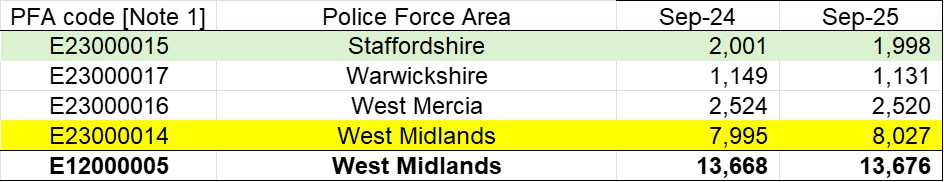


In [22]:
FTE={
    'Reported by': ['West Midlands Police', 'Staffordshire Police'],
        'Police FTE': ['8027',	'1998']}
WorkForceFTE = pd.DataFrame(FTE)
WorkForceFTE

,Reported by,Police FTE
0,West Midlands Police,8027
1,Staffordshire Police,1998


#Merge supplimentary datasets
Append Police Work Force Data

Append LSOA Data


In [ ]:
LSOAdata=pd.read_excel("/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025_All_Ranks_Scores_Deciles_Population_Denominators.xlsx")
LSOAdata

#Keep relevant columns from LSOA data

In [ ]:
LSOAdataclean=LSOAdata.loc[:, ['LSOA code (2021)','Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)','Income Rank (where 1 is most deprived)','Employment Rank (where 1 is most deprived)','Education, Skills and Training Rank (where 1 is most deprived)','Population LSOA']] #select Columns needed
LSOAdataclean

#Rename Column for easy join

In [25]:
LSOAdataclean.rename(columns={'LSOA code (2021)':'LSOA code'}, inplace=True)
LSOAdataclean

,LSOA code,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Income Rank (where 1 is most deprived),Employment Rank (where 1 is most deprived),"Education, Skills and Training Rank (where 1 is most deprived)",Population LSOA
0,E01000001,26525,33730,33708,33755,2172
1,E01000002,31203,33669,33734,33672,2044
2,E01000003,25913,25167,26985,30273,2444
3,E01000005,14807,14836,17911,15886,2391
4,E01000006,10917,7519,15286,11134,1930
...,...,...,...,...,...,...
33750,E01035758,27536,25934,24575,21842,1216
33751,E01035759,27902,26440,22891,25326,1592
33752,E01035760,27532,18127,26383,22625,1827
33753,E01035761,28981,21596,29547,24267,1955


In [26]:
#Merge LSOA data
DataMerge1=pd.merge(CleanData,LSOAdataclean,on='LSOA code',how='left')
#Merge workforce data
DataMerge=pd.merge(DataMerge1,WorkForceFTE,on='Reported by',how='left')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Income Rank (where 1 is most deprived),Employment Rank (where 1 is most deprived),"Education, Skills and Training Rank (where 1 is most deprived)",Population LSOA,Police FTE
0,2025-07,West Midlands Police,On or near Royal Park Close,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded,27056.0,23759.0,24715.0,30287.0,1554.0,8027
1,2025-07,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded,27056.0,23759.0,24715.0,30287.0,1554.0,8027
2,2025-07,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027
3,2025-07,West Midlands Police,On or near Seymour Gardens,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027
4,2025-07,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027
...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2024-07,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998
869243,2024-07,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998
869244,2024-07,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998
869245,2024-07,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998


#Creat months group for first and second 12 months for later comparision

In [27]:
#change data type for Column "Month"
DataMerge['Month'] = pd.to_datetime(DataMerge['Month'])
start_date = pd.to_datetime('2023-12')
end_date = pd.to_datetime('2024-11')

DataMerge['Month Group'] = DataMerge['Month'].apply(lambda x: 'first 12 months' if (x >= start_date and x <= end_date) else 'second 12 months')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Income Rank (where 1 is most deprived),Employment Rank (where 1 is most deprived),"Education, Skills and Training Rank (where 1 is most deprived)",Population LSOA,Police FTE,Month Group
0,2025-07-01,West Midlands Police,On or near Royal Park Close,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded,27056.0,23759.0,24715.0,30287.0,1554.0,8027,second 12 months
1,2025-07-01,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded,27056.0,23759.0,24715.0,30287.0,1554.0,8027,second 12 months
2,2025-07-01,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027,second 12 months
3,2025-07-01,West Midlands Police,On or near Seymour Gardens,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027,second 12 months
4,2025-07-01,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027,second 12 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2024-07-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869243,2024-07-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869244,2024-07-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869245,2024-07-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,1998,first 12 months


In [28]:
crime_counts = DataMerge.groupby(['Reported by','Month Group']).size().reset_index(name='CrimeCount')
crime_counts

,Reported by,Month Group,CrimeCount
0,Staffordshire Police,first 12 months,99527
1,Staffordshire Police,second 12 months,101612
2,West Midlands Police,first 12 months,344501
3,West Midlands Police,second 12 months,323607


In [29]:
#Pivot previous table to use 'Month Group' as column headers
crime_counts_pivot = crime_counts.pivot_table(index='Reported by', columns='Month Group', values='CrimeCount').reset_index()
crime_counts_pivot.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot ['Variance %'] =(crime_counts_pivot['second 12 months']-crime_counts_pivot['first 12 months'])/crime_counts_pivot['first 12 months']*100
crime_counts_pivot ['Variance %'] = crime_counts_pivot['Variance %'].round(1)
crime_counts_pivot

,Reported by,first 12 months,second 12 months,Variance %
0,Staffordshire Police,99527.0,101612.0,2.1
1,West Midlands Police,344501.0,323607.0,-6.1


In [30]:
# Variance number of crimes by types
crime_counts_type = DataMerge.groupby(['Crime type','Month Group']).size().reset_index(name='CrimeCount')
crime_counts_type
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot2 = crime_counts_type.pivot_table(index='Crime type', columns='Month Group', values='CrimeCount').reset_index()
crime_counts_pivot2.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot2 ['Variance %'] =(crime_counts_pivot2['second 12 months']-crime_counts_pivot2['first 12 months'])/crime_counts_pivot2['first 12 months']*100
crime_counts_pivot2['Variance %'] = crime_counts_pivot2['Variance %'].round(1)
crime_counts_pivot2.sort_values(by=["Variance %"],ascending=False)


,Crime type,first 12 months,second 12 months,Variance %
4,Drugs,9654.0,12390.0,28.3
10,Shoplifting,37609.0,39254.0,4.4
7,Possession of weapons,7441.0,7749.0,4.1
5,Other crime,8769.0,8747.0,-0.3
13,Violence and sexual offences,175857.0,172455.0,-1.9
0,Anti-social behaviour,40198.0,39139.0,-2.6
3,Criminal damage and arson,33451.0,31793.0,-5.0
8,Public order,28249.0,25914.0,-8.3
1,Bicycle theft,2772.0,2498.0,-9.9
11,Theft from the person,3244.0,2909.0,-10.3


#Analysis and Visualisation

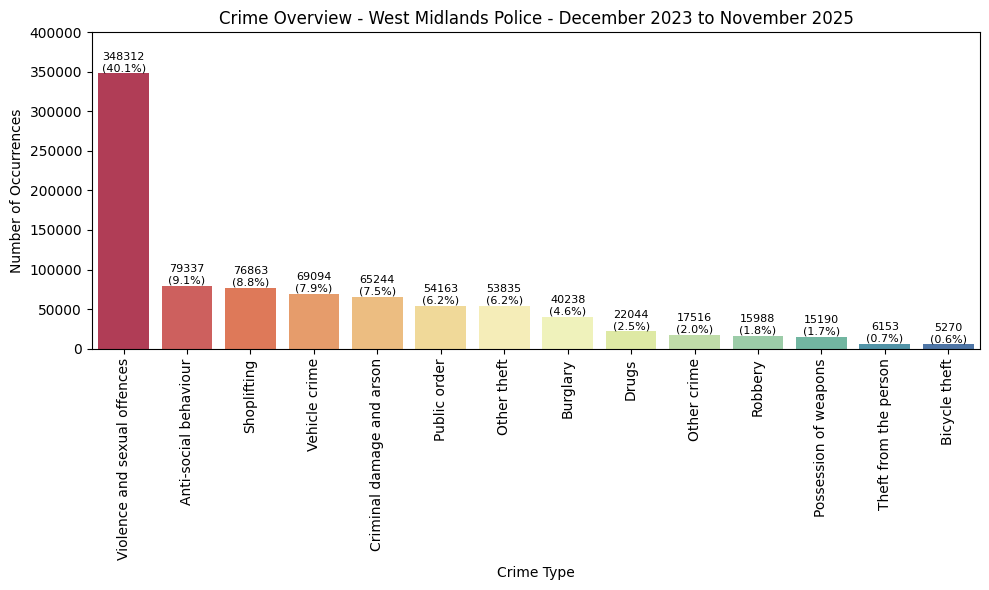

In [ ]:
#Bar Chart with percentages of total % For Crime Types
crime_type_counts = CleanData['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 400000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

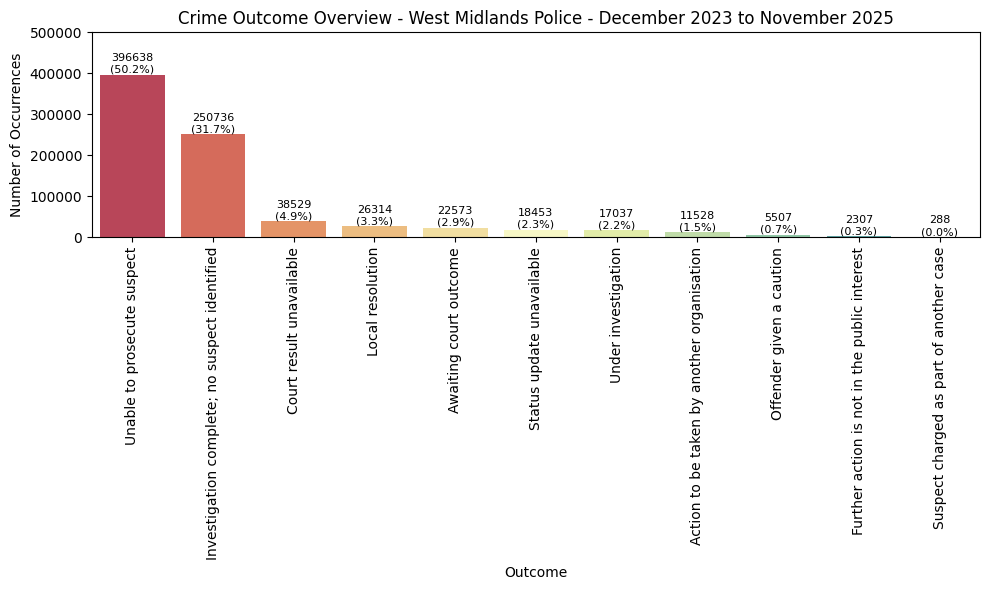

In [ ]:
#Bar Chart with percentages of total %
outcome_counts = CleanData['Last outcome category'].value_counts()
total_crimes = outcome_counts.sum()
outcome_percentages = (outcome_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='Spectral', legend=False) #viridis
plt.title('Crime Outcome Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 500000)
plt.xlabel('Outcome')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(outcome_counts.values):
    percentage = outcome_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

#Creat Radio Botton for Police Force names

In [31]:
crime_over_time = DataMerge[['Reported by','Crime type','Month']].value_counts().reset_index(name='Count')
display(crime_over_time)

# Extract unique police forces BEFORE making crime_over_time interactive
#unique_police_forces = crime_over_time['Reported by'].unique().tolist()

crime_over_time = crime_over_time.interactive()

,Reported by,Crime type,Month,Count
0,West Midlands Police,Violence and sexual offences,2024-05-01,12342
1,West Midlands Police,Violence and sexual offences,2025-07-01,12230
2,West Midlands Police,Violence and sexual offences,2024-07-01,12226
3,West Midlands Police,Violence and sexual offences,2025-06-01,11895
4,West Midlands Police,Violence and sexual offences,2024-06-01,11862
...,...,...,...,...
667,Staffordshire Police,Theft from the person,2025-06-01,18
668,Staffordshire Police,Theft from the person,2025-05-01,17
669,Staffordshire Police,Theft from the person,2024-03-01,15
670,Staffordshire Police,Theft from the person,2025-09-01,13


In [32]:
crime_over_time_pivot_full = crime_over_time.pivot_table(index=['Month', 'Crime type'], columns='Reported by', values='Count').reset_index()
crime_over_time_pivot_full.columns.name = None # Remove the column name for clarity
display(crime_over_time_pivot_full)

In [33]:
yaxis_police = pn.widgets.RadioButtonGroup(
    name='Police Force',
    options=['West Midlands Police','Staffordshire Police',],
    button_type='success'
    )
yaxis_police

RadioButtonGroup(button_type='success', name='Police Force', options=['West Midlands Police', ...], value='West Midlands Police')

In [37]:
crime_pipeline =(
    crime_over_time_pivot_full
    .groupby(['Crime type','Month'])[yaxis_police].sum()
    .reset_index()
    .sort_values(by='Month')
    .reset_index(drop=True)
                 )

crime_pipeline

In [39]:
crime_plot=crime_pipeline.hvplot(x='Month', by='Crime type', y=yaxis_police, line_width=2, width=1000, height=500, title ="Crime over time")
crime_plot

#Seasonal trend over 24 months
#corelation between LSOA metrics and Crime Rate

In [72]:
crime_counts_lsoa = DataMerge.groupby(['Reported by','LSOA name','Population LSOA']).size().reset_index(name='CrimeCount')
crime_counts_lsoa['Weighted Crime/1000 population']=(crime_counts_lsoa['CrimeCount']/crime_counts_lsoa['Population LSOA'].astype(float))*1000
crime_counts_lsoa['Weighted Crime/1000 population']=crime_counts_lsoa['Weighted Crime/1000 population'].round(2)
crime_counts_lsoa.sort_values(by=["Weighted Crime/1000 population"],ascending=False)
Police=['West Midlands Police']
a=crime_counts_lsoa[crime_counts_lsoa['Reported by'].isin(Police)]
a
a.sort_values(by=["Weighted Crime/1000 population"],ascending=False)

,Reported by,LSOA name,Population LSOA,CrimeCount,Weighted Crime/1000 population
1815,West Midlands Police,Birmingham 138A,1503.0,11997,7982.04
2881,West Midlands Police,Wolverhampton 020H,1710.0,3851,2252.05
1800,West Midlands Police,Birmingham 135C,1898.0,4258,2243.41
2732,West Midlands Police,Walsall 030A,2681.0,4701,1753.45
2500,West Midlands Police,Solihull 009A,1720.0,2957,1719.19
...,...,...,...,...,...
2602,West Midlands Police,South Staffordshire 007C,1558.0,1,0.64
2603,West Midlands Police,South Staffordshire 008A,1614.0,1,0.62
2268,West Midlands Police,North Warwickshire 007C,1732.0,1,0.58
1852,West Midlands Police,Bromsgrove 005C,1947.0,1,0.51


In [73]:
#pivot by police and population
#a.pivot_table(index='Reported by',values="Weighted Crime/1000 population")


,Weighted Crime/1000 population
Reported by,
West Midlands Police,206.922847


In [ ]:
#crime_counts['Weighted Crime/1000 population'] = (crime_counts['CrimeCount'] / crime_counts['Population LSOA'].astype(float)) * 1000

#Creat NEW Column 'Weighted Crime/1000 WTF police'
#Creat NEW Column 'Weighted Crime/1000 population'
